In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [7]:
sales_data = pd.read_csv('dataset\processed_sales.csv')
sales_data.head()

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Syed Altaf\AppData\Local\Temp\ipykernel_9224\1030230202.py:1: SyntaxWarning: invalid escape sequence '\p'
  sales_data = pd.read_csv('dataset\processed_sales.csv')


,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [13]:
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'])
prophet_df = sales_data.rename(columns={
    'Order Date': 'ds',
    'Sales': 'y'
})
prophet_df.head()



,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [14]:
model = Prophet()
model.fit(prophet_df)

11:40:06 - cmdstanpy - INFO - Chain [1] start processing
11:40:07 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1262,2018-01-25,2316.492276,-682.669487,4685.999002,2316.260814,2316.700296,-348.765800,-348.765800,-348.765800,155.813290,155.813290,155.813290,-504.579090,-504.579090,-504.579090,0.0,0.0,0.0,1967.726476
1263,2018-01-26,2317.484590,-553.585040,4940.669789,2317.228979,2317.712952,-52.577600,-52.577600,-52.577600,419.595791,419.595791,419.595791,-472.173391,-472.173391,-472.173391,0.0,0.0,0.0,2264.906990
1264,2018-01-27,2318.476904,-719.137815,4761.178999,2318.192164,2318.727109,-424.470202,-424.470202,-424.470202,21.920903,21.920903,21.920903,-446.391105,-446.391105,-446.391105,0.0,0.0,0.0,1894.006702
1265,2018-01-28,2319.469218,-683.657206,4661.741108,2319.158724,2319.745131,-224.455926,-224.455926,-224.455926,203.818580,203.818580,203.818580,-428.274506,-428.274506,-428.274506,0.0,0.0,0.0,2095.013291
1266,2018-01-29,2320.461532,-469.850539,5044.698757,2320.128564,2320.764980,-7.192088,-7.192088,-7.192088,411.471448,411.471448,411.471448,-418.663536,-418.663536,-418.663536,0.0,0.0,0.0,2313.269444


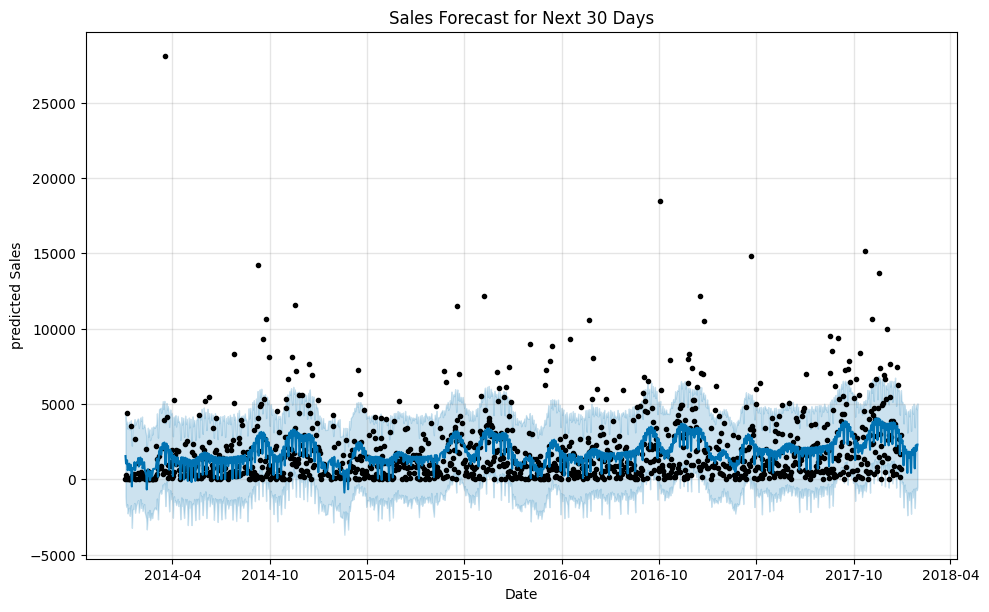

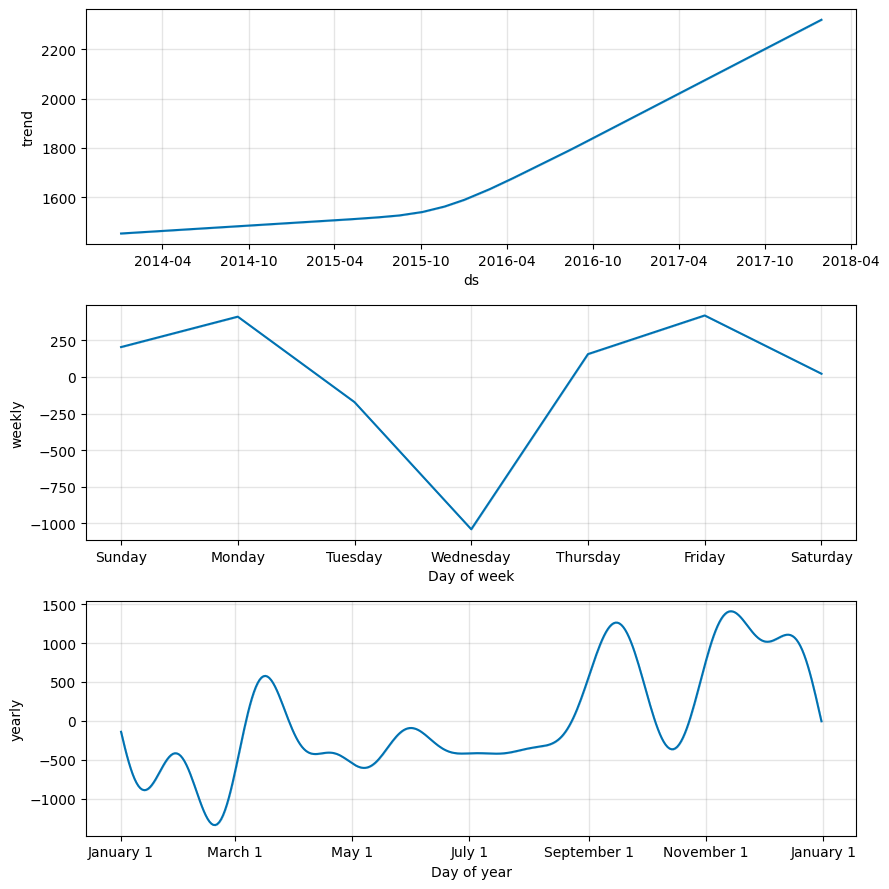

In [16]:
model.plot(forecast)
plt.title('Sales Forecast for Next 30 Days')
plt.xlabel('Date')
plt.ylabel('predicted Sales')
model.plot_components(forecast)
plt.show()
forecast[['ds', 'yhat']].rename(columns={'ds': 'Order Date', 'yhat': 'Predicted Sales'}).tail(30).to_csv("forecasted_sales.csv", index=False )

In [17]:
train = prophet_df.iloc[:-60]
test = prophet_df.iloc[-60:]
model = Prophet()
model.fit(train)    
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

pred = forecast[['ds', 'yhat']].tail(60)
test= test.merge(pred, on='ds')

KeyError: 'yhat'

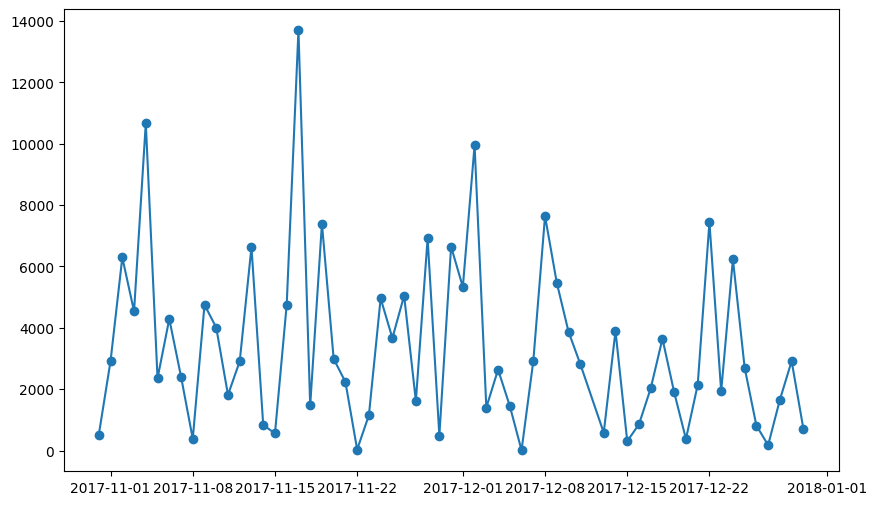

In [ ]:
# make sure predictions align by date
test = test.merge(forecast[['ds', 'yhat']], on='ds', how='left')

# check
print(test[['ds', 'yhat']].head())
print("missing yhat:", test['yhat'].isna().sum())

plt.figure(figsize=(10, 6))
plt.plot(test['ds'], test['y'], label='Actual Sales', marker='o')
plt.plot(test['ds'], test['yhat'], label='Predicted Sales', marker='x')
plt.title('Sales Forecast vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()